# Price and feature exploration

This notebook visualizes historical stock-price windows together with fixed
Fibonacci levels and, later, additional price-derived features.

In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from read_valid_samples import load_valid_samples_npz
from amgm.utils.common import calculate_fibLevels
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D

In [2]:
def resolve_repository_path(relative_path):
    current = Path.cwd().resolve()
    for root in (current, *current.parents):
        candidate = root / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_path} from {current} or its parents")
npz_path = resolve_repository_path(Path("Data/Synthetic/synthetic_rollout_MC_valid_samples.npz"))
loaded_samples = load_valid_samples_npz(str(npz_path), mode="MC")
print(f"Loaded {len(loaded_samples['samples'])} paths")

Loaded 10000 paths


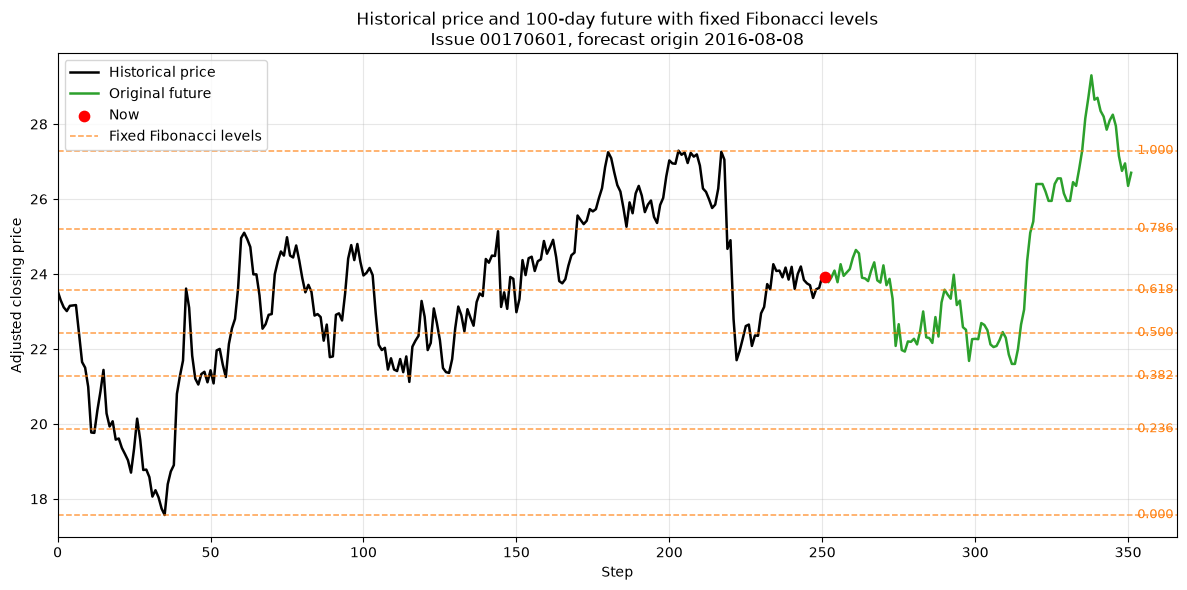

In [3]:
SAMPLE_INDEX = 175
sample = loaded_samples["samples"][SAMPLE_INDEX]

history_normalized = np.asarray(sample["hist"], dtype=float).reshape(-1)
history_real = history_normalized * float(sample["price_range"]) + float(sample["price_min"])
fib_levels_real, _ = calculate_fibLevels(history_real[None, :])

issue_id = str(sample["issue_id"])
test_date = str(sample["test_date"])
steps = np.arange(len(history_real))

fib_labels = ["0.000", "0.236", "0.382", "0.500", "0.618", "0.786", "1.000"]
future_real = np.asarray(sample["original_price"], dtype=float).reshape(-1)[:101]
future_steps = np.arange(steps[-1], steps[-1] + len(future_real))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(steps, history_real, color="black", linewidth=1.8, label="Historical price")
ax.plot(future_steps, future_real, color="tab:green", linewidth=1.8, label="Original future")
ax.scatter(steps[-1], history_real[-1], color="red", s=55, zorder=5, label="Now")

for index, (level, label) in enumerate(zip(fib_levels_real[0], fib_labels)):
    ax.axhline(level, color="tab:orange", linestyle="--", linewidth=1.1, alpha=0.75, label="Fixed Fibonacci levels" if index == 0 else None)
    ax.text(future_steps[-1] + 2, level, label, color="tab:orange", va="center", fontsize=9)

ax.set_title(f"Historical price and 100-day future with fixed Fibonacci levels\nIssue {issue_id}, forecast origin {test_date}")
ax.set_xlabel("Step")
ax.set_ylabel("Adjusted closing price")
ax.set_xlim(steps[0], future_steps[-1] + 15)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

In [4]:
def distance_to_sma(prices, window=21):
    """Proportional distance between price and its simple moving average."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    sma = prices.rolling(window, min_periods=window).mean()
    return (prices - sma) / sma

def distance_to_ema(prices, span=21):
    """Proportional distance between price and its exponential moving average."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    ema = prices.ewm(span=span, adjust=False, min_periods=span).mean()
    return (prices - ema) / ema

def moving_average_slope(prices, ma_window=21, slope_horizon=5):
    """Average daily proportional change in the SMA over a chosen horizon."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    sma = prices.rolling(ma_window, min_periods=ma_window).mean()
    return (sma - sma.shift(slope_horizon)) / (slope_horizon * sma.shift(slope_horizon))

def rolling_volatility(prices, window=21, annualize=False):
    """Rolling population standard deviation of daily log returns."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    log_returns = np.log(prices / prices.shift(1))
    volatility = log_returns.rolling(window, min_periods=window).std(ddof=0)
    return volatility * np.sqrt(252) if annualize else volatility

def momentum_return(prices, horizon=21):
    """Simple cumulative return over the selected horizon."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    return prices / prices.shift(horizon) - 1.0

def relative_strength_index(prices, window=14):
    """Wilder-style RSI based on exponentially smoothed gains and losses."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    changes = prices.diff()
    gains = changes.clip(lower=0.0)
    losses = -changes.clip(upper=0.0)
    average_gain = gains.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    average_loss = losses.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    relative_strength = average_gain / average_loss.replace(0.0, np.nan)
    rsi = 100.0 - 100.0 / (1.0 + relative_strength)
    rsi = rsi.mask((average_loss == 0.0) & (average_gain > 0.0), 100.0)
    return rsi.mask((average_loss == 0.0) & (average_gain == 0.0), 50.0)

def rolling_range_position(prices, window=21):
    """Position of price between its rolling minimum and maximum."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    rolling_low = prices.rolling(window, min_periods=window).min()
    rolling_high = prices.rolling(window, min_periods=window).max()
    rolling_range = (rolling_high - rolling_low).replace(0.0, np.nan)
    return (prices - rolling_low) / rolling_range

def rolling_drawdown(prices, window=63):
    """Current proportional decline from the highest price in the rolling window."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    rolling_peak = prices.rolling(window, min_periods=window).max()
    return prices / rolling_peak - 1.0

def bollinger_position(prices, window=21):
    """Price distance from its SMA measured in rolling price standard deviations."""
    prices = pd.Series(np.asarray(prices, dtype=float))
    sma = prices.rolling(window, min_periods=window).mean()
    rolling_std = prices.rolling(window, min_periods=window).std(ddof=0).replace(0.0, np.nan)
    return (prices - sma) / rolling_std

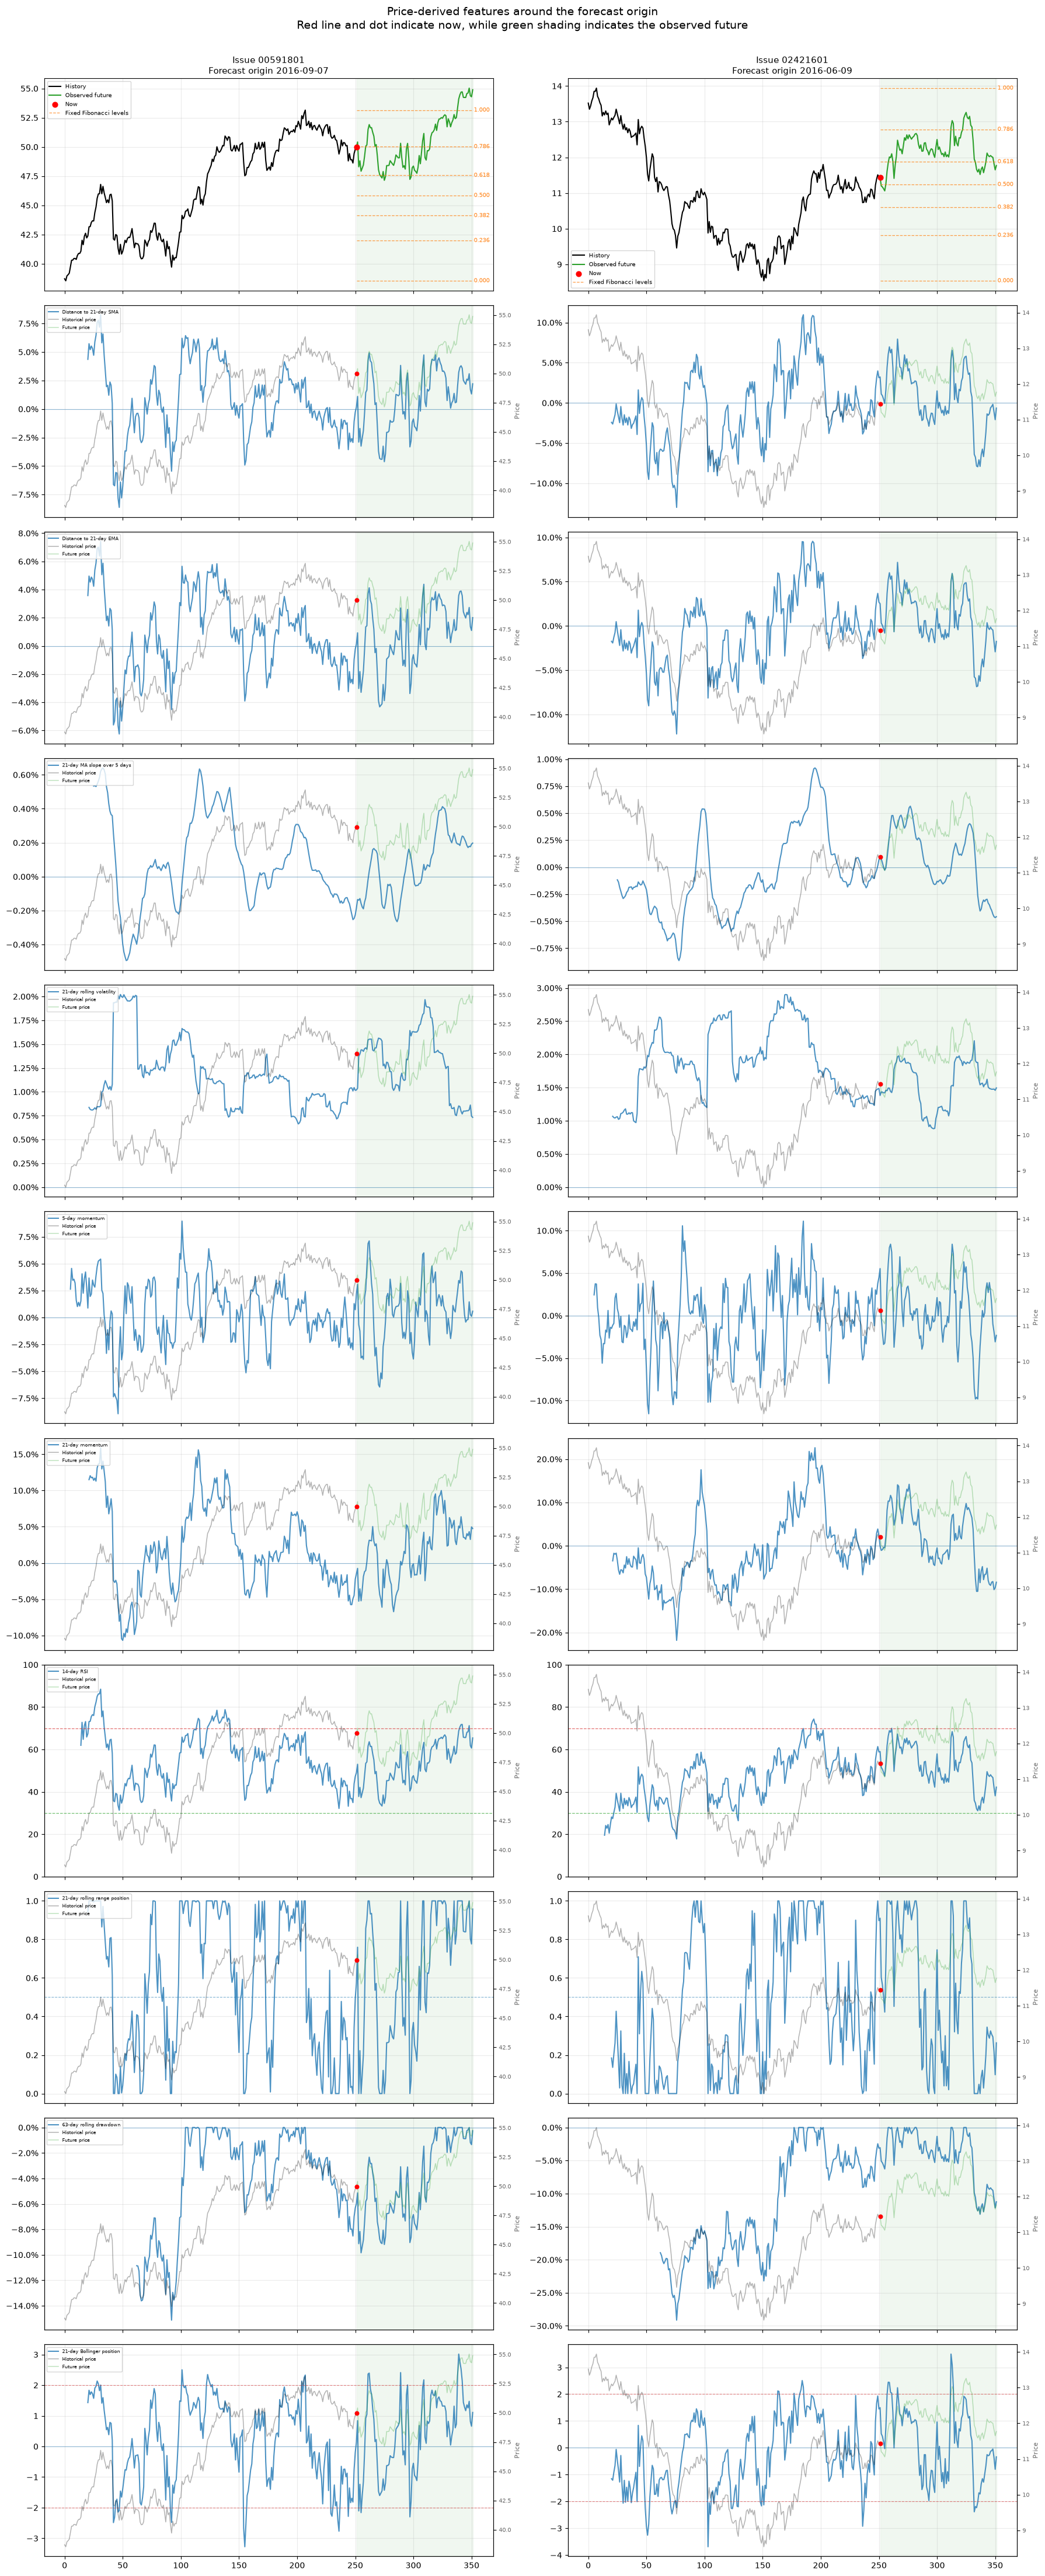

In [20]:
RANDOM_SELECTION_SEED = 42
NUMBER_OF_SAMPLES = 2
FUTURE_DAYS = 100

# Select distinct base samples so that different MC realizations of the same
# issue and forecast date cannot occupy multiple columns.
distinct_samples = {}
for candidate in loaded_samples["samples"]:
    if candidate["is_valid"]:
        distinct_samples.setdefault(candidate["base_sample_id"], candidate)

available_samples = list(distinct_samples.values())
if len(available_samples) < NUMBER_OF_SAMPLES:
    raise ValueError(f"Only {len(available_samples)} distinct valid base samples are available")

rng = np.random.default_rng(RANDOM_SELECTION_SEED)
selected_indices = rng.choice(len(available_samples), size=NUMBER_OF_SAMPLES, replace=False)
selected_samples = [available_samples[index] for index in selected_indices]

def prepare_sample(sample, future_days=100):
    """Recover real prices and append at most 100 observed future days."""
    history = np.asarray(sample["hist"], dtype=float).reshape(-1)
    history = history * float(sample["price_range"]) + float(sample["price_min"])
    future = np.asarray(sample["original_price"], dtype=float).reshape(-1)[:future_days + 1]

    # Both paths should contain the forecast-origin price, so avoid duplicating it.
    if future.size and np.isclose(future[0], history[-1], rtol=1e-5, atol=1e-6):
        combined = np.concatenate([history, future[1:]])
    else:
        combined = np.concatenate([history, future[:future_days]])

    now_index = len(history) - 1
    fib_levels, _ = calculate_fibLevels(history[None, :])
    return history, combined, now_index, fib_levels[0]

feature_specs = [
    ("Price and fixed Fibonacci levels", None, "Price", None),
    ("Distance to 21-day SMA", lambda x: distance_to_sma(x, window=21), "Distance", "percent"),
    ("Distance to 21-day EMA", lambda x: distance_to_ema(x, span=21), "Distance", "percent"),
    ("21-day MA slope over 5 days", lambda x: moving_average_slope(x, ma_window=21, slope_horizon=5), "Slope per day", "percent"),
    ("21-day rolling volatility", lambda x: rolling_volatility(x, window=21), "Volatility", "percent"),
    ("5-day momentum", lambda x: momentum_return(x, horizon=5), "Return", "percent"),
    ("21-day momentum", lambda x: momentum_return(x, horizon=21), "Return", "percent"),
    ("14-day RSI", lambda x: relative_strength_index(x, window=14), "RSI", "rsi"),
    ("21-day rolling range position", lambda x: rolling_range_position(x, window=21), "Position", "unit"),
    ("63-day rolling drawdown", lambda x: rolling_drawdown(x, window=63), "Drawdown", "percent"),
    ("21-day Bollinger position", lambda x: bollinger_position(x, window=21), "Standard deviations", "bollinger"),
]

fig, axes = plt.subplots(
    len(feature_specs),
    NUMBER_OF_SAMPLES,
    figsize=(9 * NUMBER_OF_SAMPLES, 4 * len(feature_specs)),
    sharex="col",
    squeeze=False,
)

fib_labels = ["0.000", "0.236", "0.382", "0.500", "0.618", "0.786", "1.000"]
feature_color = "tab:blue"
future_shading_color = "#E8F3E8"

for column, sample in enumerate(selected_samples):
    history, combined_prices, now_index, fib_levels = prepare_sample(sample, FUTURE_DAYS)
    x_values = np.arange(len(combined_prices))
    future_end = len(combined_prices) - 1
    issue_id = str(sample["issue_id"])
    test_date = str(sample["test_date"])

    for row, (feature_name, feature_function, ylabel, display_type) in enumerate(feature_specs):
        ax = axes[row, column]
        ax.axvspan(now_index, future_end, color=future_shading_color, alpha=0.65, zorder=0)
        ax.grid(True, alpha=0.25)

        if row == 0:
            ax.plot(x_values[:now_index + 1], combined_prices[:now_index + 1], color="black", linewidth=1.5, label="History")
            ax.plot(x_values[now_index:], combined_prices[now_index:], color="tab:green", linewidth=1.5, label="Observed future")
            ax.scatter(now_index, combined_prices[now_index], color="red", s=40, zorder=5, label="Now")

            for level_index, (level, label) in enumerate(zip(fib_levels, fib_labels)):
                ax.hlines(level, now_index, future_end, color="tab:orange", linestyle="--", linewidth=0.9, alpha=0.75, label="Fixed Fibonacci levels" if level_index == 0 else None)
                ax.text(future_end + 1, level, label, color="tab:orange", va="center", fontsize=7)

            ax.set_title(f"Issue {issue_id}\nForecast origin {test_date}", fontsize=11)
            ax.legend(loc="best", fontsize=7)
        else:
            feature_values = feature_function(combined_prices).to_numpy()

            # Feature on the primary y-axis.
            feature_line = ax.plot(x_values, feature_values, color=feature_color, linewidth=1.5, label=feature_name, alpha=0.8)

            # Price on a secondary y-axis.
            price_ax = ax.twinx()
            history_line = price_ax.plot(x_values[:now_index + 1], combined_prices[:now_index + 1], color="black", linewidth=1.1, alpha=0.3, label="Historical price")
            future_line = price_ax.plot(x_values[now_index:], combined_prices[now_index:], color="tab:green", linewidth=1.1, alpha=0.3, label="Future price")
            price_ax.scatter(now_index, combined_prices[now_index], color="red", s=22, zorder=5)
            price_ax.set_ylabel("Price", color="dimgray", fontsize=8)
            price_ax.tick_params(axis="y", labelcolor="dimgray", labelsize=7)
            price_ax.grid(False)

            if display_type in {"percent", "bollinger"}:
                ax.axhline(0.0, color="tab:blue", linewidth=0.8, alpha=0.45)
            if display_type == "percent":
                ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
            if display_type == "rsi":
                ax.axhline(70.0, color="tab:red", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.axhline(30.0, color="tab:green", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.set_ylim(0.0, 100.0)
            if display_type == "unit":
                ax.axhline(0.5, color="tab:blue", linestyle="--", linewidth=0.8, alpha=0.55)
                ax.set_ylim(-0.05, 1.05)
            if display_type == "bollinger":
                ax.axhline(2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)
                ax.axhline(-2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)

            # Add a combined legend only in the first sample column.
            if column == 0:
                combined_lines = feature_line + history_line + future_line
                ax.legend(combined_lines, [line.get_label() for line in combined_lines], loc="upper left", fontsize=6)

fig.suptitle(
    "Price-derived features around the forecast origin\n"
    "Red line and dot indicate now, while green shading indicates the observed future",
    fontsize=14,
    y=1.002,
)
fig.tight_layout()
plt.show()

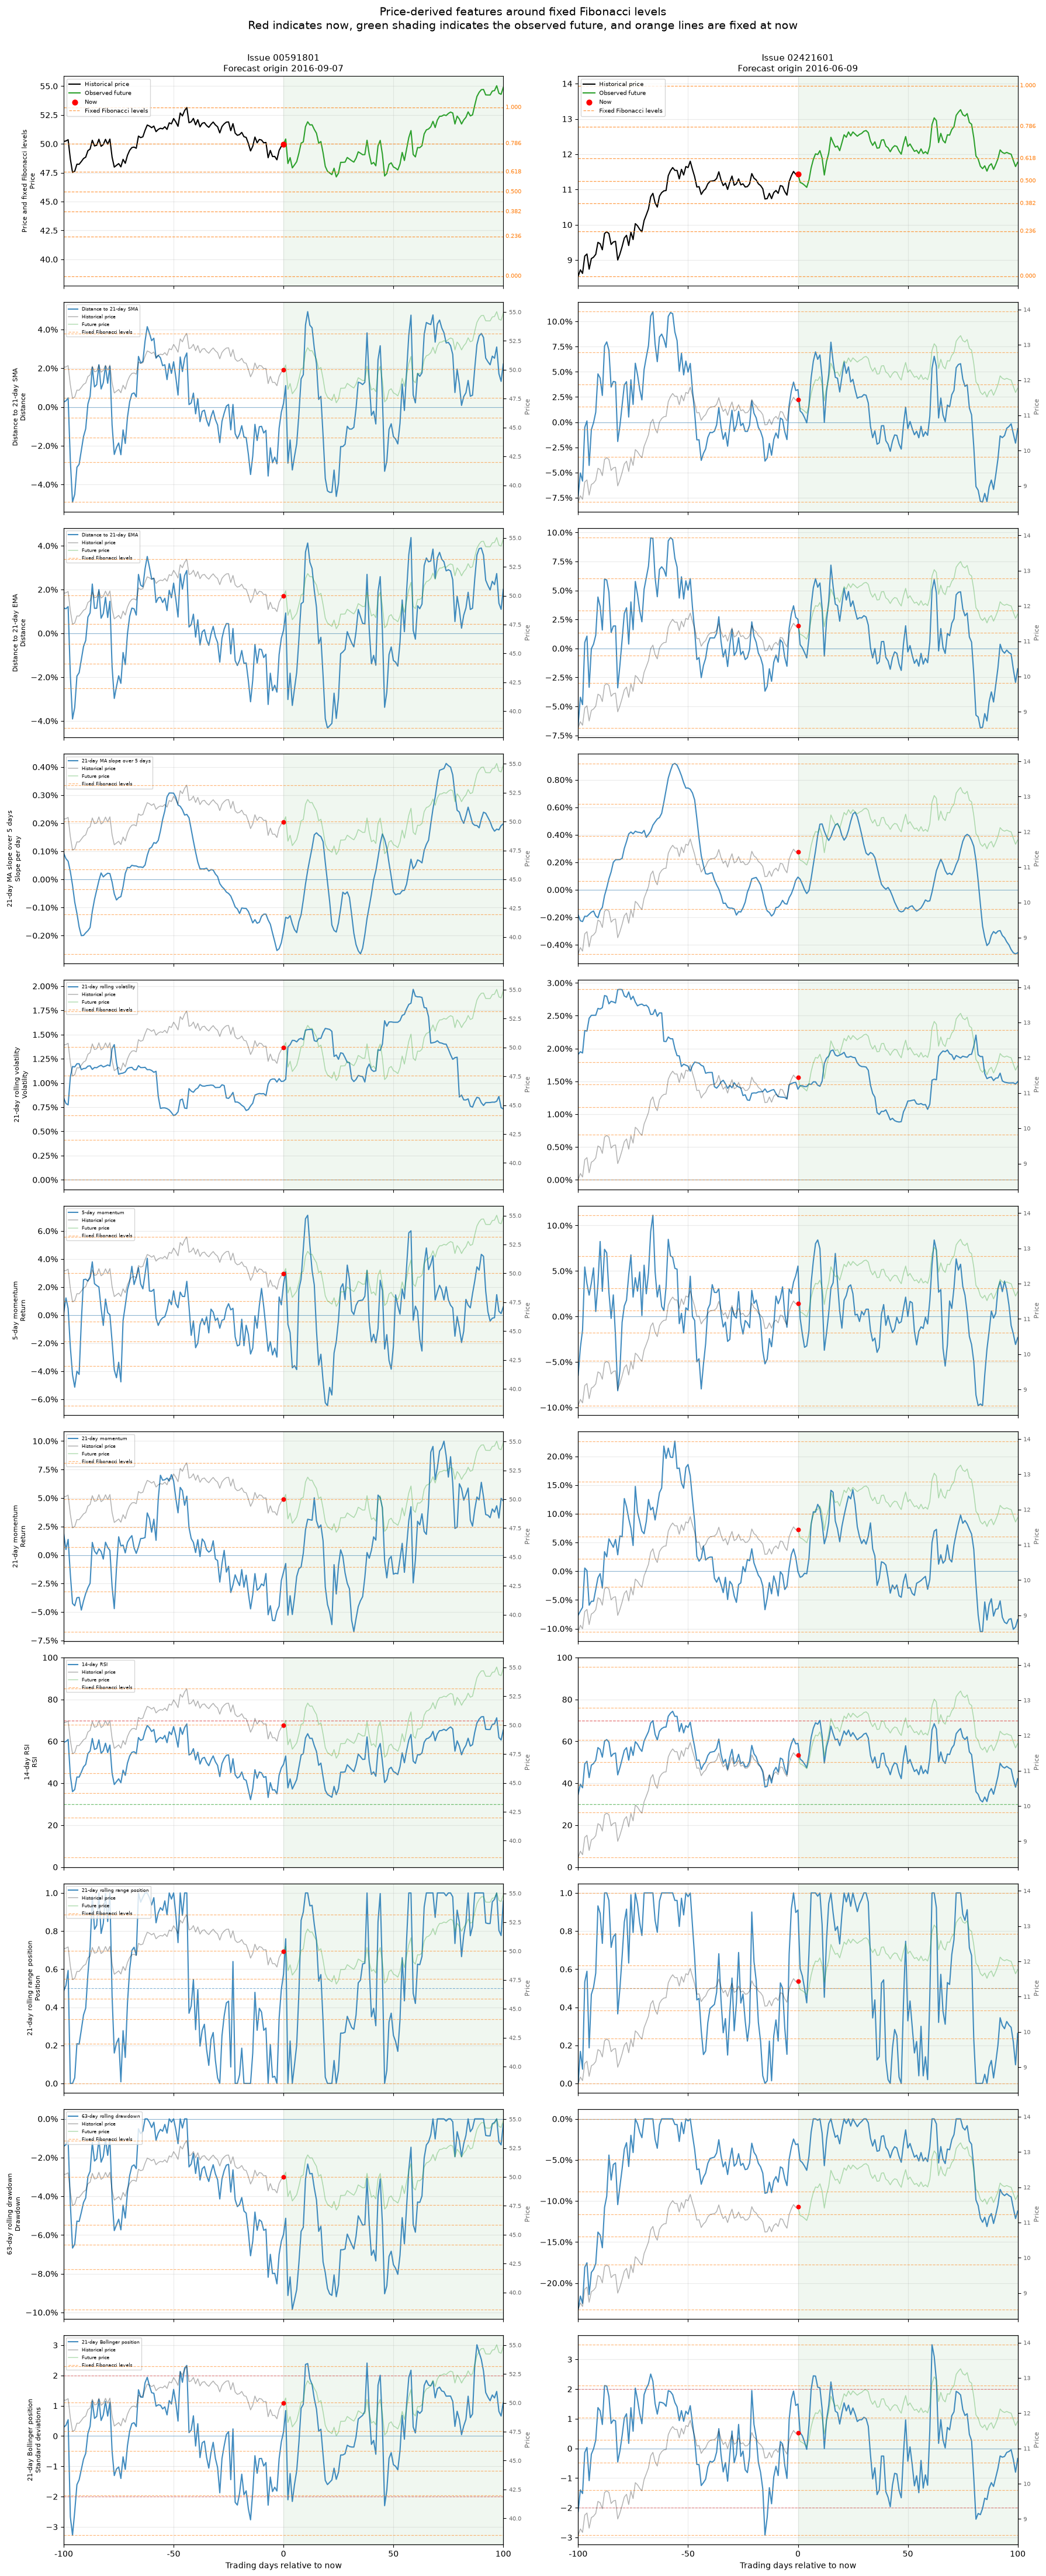

In [26]:
# %%
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
from amgm.utils.common import calculate_fibLevels

RANDOM_SELECTION_SEED = 42
NUMBER_OF_SAMPLES = 2
PAST_DAYS = 100
FUTURE_DAYS = 100

# Select distinct base samples so different MC realizations of the same
# issue and forecast date cannot occupy multiple columns.
distinct_samples = {}
for candidate in loaded_samples["samples"]:
    if candidate["is_valid"]:
        distinct_samples.setdefault(candidate["base_sample_id"], candidate)

available_samples = list(distinct_samples.values())
if len(available_samples) < NUMBER_OF_SAMPLES:
    raise ValueError(f"Only {len(available_samples)} distinct valid base samples are available")

rng = np.random.default_rng(RANDOM_SELECTION_SEED)
selected_indices = rng.choice(len(available_samples), size=NUMBER_OF_SAMPLES, replace=False)
selected_samples = [available_samples[index] for index in selected_indices]

def prepare_sample(sample, future_days=100):
    """Recover complete history and append at most 100 observed future days."""
    history = np.asarray(sample["hist"], dtype=float).reshape(-1)
    history = history * float(sample["price_range"]) + float(sample["price_min"])
    future = np.asarray(sample["original_price"], dtype=float).reshape(-1)[:future_days + 1]

    # Avoid duplicating the forecast-origin price if both paths contain it.
    if future.size and np.isclose(future[0], history[-1], rtol=1e-5, atol=1e-6):
        combined = np.concatenate([history, future[1:]])
    else:
        combined = np.concatenate([history, future[:future_days]])

    now_index = len(history) - 1

    # Fibonacci levels use the complete historical seed window, not only the
    # 100 historical days displayed in the figure.
    fib_levels, _ = calculate_fibLevels(history[None, :])
    return history, combined, now_index, fib_levels[0]

feature_specs = [
    ("Price and fixed Fibonacci levels", None, "Price", None),
    ("Distance to 21-day SMA", lambda x: distance_to_sma(x, window=21), "Distance", "percent"),
    ("Distance to 21-day EMA", lambda x: distance_to_ema(x, span=21), "Distance", "percent"),
    ("21-day MA slope over 5 days", lambda x: moving_average_slope(x, ma_window=21, slope_horizon=5), "Slope per day", "percent"),
    ("21-day rolling volatility", lambda x: rolling_volatility(x, window=21), "Volatility", "percent"),
    ("5-day momentum", lambda x: momentum_return(x, horizon=5), "Return", "percent"),
    ("21-day momentum", lambda x: momentum_return(x, horizon=21), "Return", "percent"),
    ("14-day RSI", lambda x: relative_strength_index(x, window=14), "RSI", "rsi"),
    ("21-day rolling range position", lambda x: rolling_range_position(x, window=21), "Position", "unit"),
    ("63-day rolling drawdown", lambda x: rolling_drawdown(x, window=63), "Drawdown", "percent"),
    ("21-day Bollinger position", lambda x: bollinger_position(x, window=21), "Standard deviations", "bollinger"),
]

fig, axes = plt.subplots(
    len(feature_specs),
    NUMBER_OF_SAMPLES,
    figsize=(9 * NUMBER_OF_SAMPLES, 4 * len(feature_specs)),
    sharex="col",
    squeeze=False,
)

fib_labels = ["0.000", "0.236", "0.382", "0.500", "0.618", "0.786", "1.000"]
feature_color = "tab:blue"
fib_color = "tab:orange"
future_shading_color = "#E8F3E8"

for column, sample in enumerate(selected_samples):
    history, combined_prices, now_index, fib_levels = prepare_sample(sample, FUTURE_DAYS)
    x_values = np.arange(len(combined_prices))
    future_end = min(now_index + FUTURE_DAYS, len(combined_prices) - 1)
    visible_start = max(0, now_index - PAST_DAYS)
    visible_end = future_end
    issue_id = str(sample["issue_id"])
    test_date = str(sample["test_date"])

    for row, (feature_name, feature_function, ylabel, display_type) in enumerate(feature_specs):
        ax = axes[row, column]
        ax.axvspan(now_index, visible_end, color=future_shading_color, alpha=0.65, zorder=0)
        ax.set_xlim(visible_start, visible_end)
        ax.grid(True, alpha=0.25)

        if row == 0:
            ax.plot(
                x_values[visible_start:now_index + 1],
                combined_prices[visible_start:now_index + 1],
                color="black",
                linewidth=1.5,
                label="Historical price",
            )
            ax.plot(
                x_values[now_index:visible_end + 1],
                combined_prices[now_index:visible_end + 1],
                color="tab:green",
                linewidth=1.5,
                label="Observed future",
            )
            ax.scatter(now_index, combined_prices[now_index], color="red", s=40, zorder=6, label="Now")

            for level_index, (level, label) in enumerate(zip(fib_levels, fib_labels)):
                ax.hlines(
                    level,
                    visible_start,
                    visible_end,
                    color=fib_color,
                    linestyle="--",
                    linewidth=0.9,
                    alpha=0.75,
                    label="Fixed Fibonacci levels" if level_index == 0 else None,
                )
                ax.text(visible_end + 1, level, label, color=fib_color, va="center", fontsize=7)

            ax.set_title(f"Issue {issue_id}\nForecast origin {test_date}", fontsize=11)
            ax.legend(loc="best", fontsize=7)

        else:
            # Compute the feature using the full available path so the left edge
            # still has values based on prices preceding the displayed window.
            feature_values = feature_function(combined_prices).to_numpy()

            feature_line = ax.plot(
                x_values[visible_start:visible_end + 1],
                feature_values[visible_start:visible_end + 1],
                color=feature_color,
                linewidth=1.5,
                alpha=0.85,
                label=feature_name,
                zorder=3,
            )

            # Plot price and Fibonacci levels on a secondary price axis.
            price_ax = ax.twinx()
            history_line = price_ax.plot(
                x_values[visible_start:now_index + 1],
                combined_prices[visible_start:now_index + 1],
                color="black",
                linewidth=1.1,
                alpha=0.3,
                label="Historical price",
                zorder=2,
            )
            future_line = price_ax.plot(
                x_values[now_index:visible_end + 1],
                combined_prices[now_index:visible_end + 1],
                color="tab:green",
                linewidth=1.1,
                alpha=0.35,
                label="Future price",
                zorder=2,
            )
            price_ax.scatter(now_index, combined_prices[now_index], color="red", s=22, zorder=5)

            for level_index, (level, label) in enumerate(zip(fib_levels, fib_labels)):
                price_ax.hlines(
                    level,
                    visible_start,
                    visible_end,
                    color=fib_color,
                    linestyle="--",
                    linewidth=0.85,
                    alpha=0.55,
                    label="Fixed Fibonacci levels" if level_index == 0 else None,
                    zorder=1,
                )
                #price_ax.text(visible_end + 1, level, label, color=fib_color, va="center", fontsize=6)

            price_ax.set_xlim(visible_start, visible_end)
            price_ax.set_ylabel("Price", color="dimgray", fontsize=8)
            price_ax.tick_params(axis="y", labelcolor="dimgray", labelsize=7)
            price_ax.grid(False)

            if display_type in {"percent", "bollinger"}:
                ax.axhline(0.0, color=feature_color, linewidth=0.8, alpha=0.45)

            if display_type == "percent":
                ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

            if display_type == "rsi":
                ax.axhline(70.0, color="tab:red", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.axhline(30.0, color="tab:green", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.set_ylim(0.0, 100.0)

            if display_type == "unit":
                ax.axhline(0.5, color=feature_color, linestyle="--", linewidth=0.8, alpha=0.55)
                ax.set_ylim(-0.05, 1.05)

            if display_type == "bollinger":
                ax.axhline(2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)
                ax.axhline(-2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)

            if column == 0:
                fib_legend_line = plt.Line2D(
                    [0],
                    [0],
                    color=fib_color,
                    linestyle="--",
                    linewidth=0.85,
                    alpha=0.55,
                    label="Fixed Fibonacci levels",
                )
                combined_lines = feature_line + history_line + future_line + [fib_legend_line]
                ax.legend(
                    combined_lines,
                    [line.get_label() for line in combined_lines],
                    loc="upper left",
                    fontsize=6,
                )

        if column == 0:
            ax.set_ylabel(f"{feature_name}\n{ylabel}", fontsize=8)

        if row == len(feature_specs) - 1:
            relative_ticks = np.array([-100, -50, 0, 50, 100])
            absolute_ticks = now_index + relative_ticks
            valid_tick_mask = (absolute_ticks >= visible_start) & (absolute_ticks <= visible_end)
            ax.set_xticks(absolute_ticks[valid_tick_mask])
            ax.set_xticklabels(relative_ticks[valid_tick_mask])
            ax.set_xlabel("Trading days relative to now")

fig.suptitle(
    "Price-derived features around fixed Fibonacci levels\n"
    "Red indicates now, green shading indicates the observed future, and orange lines are fixed at now",
    fontsize=14,
    y=1.001,
)
fig.tight_layout()
plt.show()

Issue 02421601, forecast origin 2017-03-16
{'hover': 1, 'breakout': 0, 'pullback': 1, 'timeout': 1}
Issue 00694601, forecast origin 2016-07-29
{'hover': 2, 'breakout': 1, 'pullback': 2, 'timeout': 1}


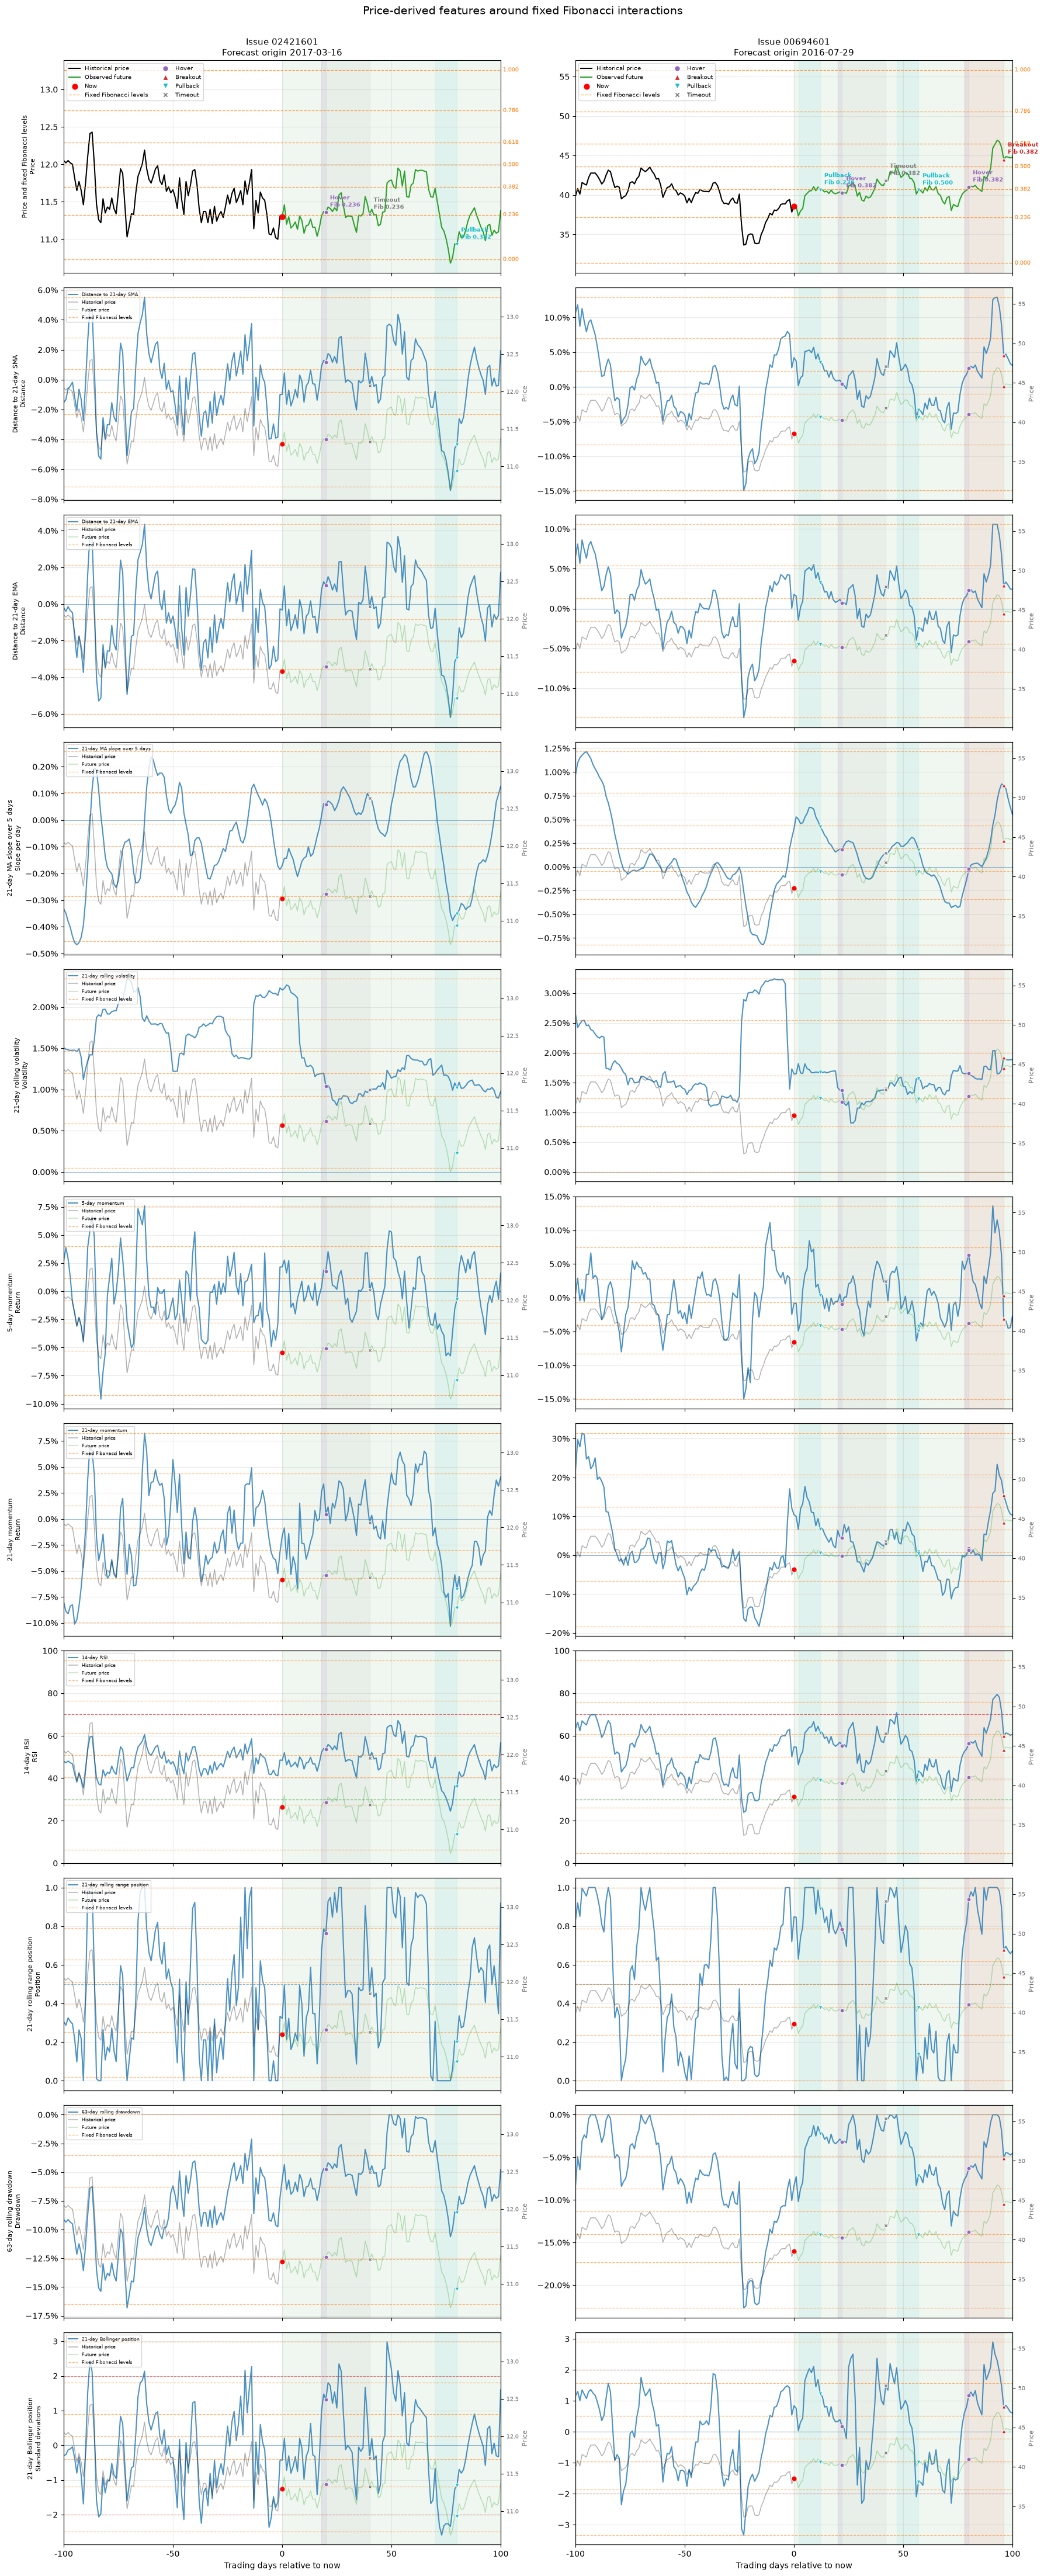

In [39]:
from fibonacci_state_detection import EventType, detect_fibonacci_interactions
RANDOM_SELECTION_SEED = 20
NUMBER_OF_SAMPLES = 2
PAST_DAYS = 100
FUTURE_DAYS = 100

FIB_INTERACTION_TOLERANCE = 0.02
FIB_MIN_DWELL_STEPS = 3
FIB_CONFIRMATION_STEPS = 10
FIB_MAX_DWELL_STEPS = 20

# Select distinct base samples so different MC realizations of the same
# issue and forecast date cannot occupy multiple columns.
distinct_samples = {}
for candidate in loaded_samples["samples"]:
    if candidate["is_valid"]:
        distinct_samples.setdefault(candidate["base_sample_id"], candidate)

available_samples = list(distinct_samples.values())
if len(available_samples) < NUMBER_OF_SAMPLES:
    raise ValueError(f"Only {len(available_samples)} distinct valid base samples are available")

rng = np.random.default_rng(RANDOM_SELECTION_SEED)
selected_indices = rng.choice(len(available_samples), size=NUMBER_OF_SAMPLES, replace=False)
selected_samples = [available_samples[index] for index in selected_indices]

def prepare_sample(sample, future_days=100):
    """Recover prices, calculate fixed levels, and detect future interactions."""
    history = np.asarray(sample["hist"], dtype=float).reshape(-1)
    history = history * float(sample["price_range"]) + float(sample["price_min"])
    future = np.asarray(sample["original_price"], dtype=float).reshape(-1)[:future_days + 1]

    # Ensure that the detector's future path begins at the forecast-origin price.
    if future.size == 0:
        raise ValueError("The sample has no original future prices")
    if np.isclose(future[0], history[-1], rtol=1e-5, atol=1e-6):
        future_with_origin = future
        combined = np.concatenate([history, future[1:]])
    else:
        future_with_origin = np.concatenate([[history[-1]], future[:future_days]])
        combined = np.concatenate([history, future[:future_days]])

    now_index = len(history) - 1

    # Fibonacci levels use the complete historical seed window.
    fib_levels_real, _ = calculate_fibLevels(history[None, :])
    fib_levels_real = fib_levels_real[0]

    # The detector expects the same normalized coordinate system in which
    # tolerance=0.02 means two percent of the historical price range.
    history_min = float(np.min(history))
    history_range = max(float(np.max(history) - history_min), 1e-8)
    future_normalized = (future_with_origin - history_min) / history_range
    fib_levels_normalized = (fib_levels_real - history_min) / history_range

    detected_events = detect_fibonacci_interactions(
        future_normalized,
        fib_levels_normalized,
        tolerance=FIB_INTERACTION_TOLERANCE,
        min_dwell_steps=FIB_MIN_DWELL_STEPS,
        confirmation_steps=FIB_CONFIRMATION_STEPS,
        max_dwell_steps=FIB_MAX_DWELL_STEPS,
    )

    # Convert future-relative detector indices to combined-path indices.
    events = []
    for event in detected_events:
        level_index = int(np.argmin(np.abs(fib_levels_normalized - event["fib_level"])))
        converted_event = dict(event)
        converted_event["fib_level_index"] = level_index
        converted_event["fib_level_real"] = float(fib_levels_real[level_index])

        for index_name in ("entry_index", "consolidation_index", "hover_index", "exit_index", "confirmation_end_index", "output_index"):
            detector_index = converted_event.get(index_name)
            converted_event[f"absolute_{index_name}"] = None if detector_index is None else now_index + int(detector_index)

        events.append(converted_event)

    return history, combined, now_index, fib_levels_real, events

feature_specs = [
    ("Price and fixed Fibonacci levels", None, "Price", None),
    ("Distance to 21-day SMA", lambda x: distance_to_sma(x, window=21), "Distance", "percent"),
    ("Distance to 21-day EMA", lambda x: distance_to_ema(x, span=21), "Distance", "percent"),
    ("21-day MA slope over 5 days", lambda x: moving_average_slope(x, ma_window=21, slope_horizon=5), "Slope per day", "percent"),
    ("21-day rolling volatility", lambda x: rolling_volatility(x, window=21), "Volatility", "percent"),
    ("5-day momentum", lambda x: momentum_return(x, horizon=5), "Return", "percent"),
    ("21-day momentum", lambda x: momentum_return(x, horizon=21), "Return", "percent"),
    ("14-day RSI", lambda x: relative_strength_index(x, window=14), "RSI", "rsi"),
    ("21-day rolling range position", lambda x: rolling_range_position(x, window=21), "Position", "unit"),
    ("63-day rolling drawdown", lambda x: rolling_drawdown(x, window=63), "Drawdown", "percent"),
    ("21-day Bollinger position", lambda x: bollinger_position(x, window=21), "Standard deviations", "bollinger"),
]

event_styles = {
    EventType.HOVER: {"color": "tab:purple", "marker": "o", "label": "Hover"},
    EventType.BREAKOUT: {"color": "tab:red", "marker": "^", "label": "Breakout"},
    EventType.PULLBACK: {"color": "tab:cyan", "marker": "v", "label": "Pullback"},
    EventType.TIMEOUT: {"color": "tab:gray", "marker": "X", "label": "Timeout"},
}

def draw_event_intervals(ax, events, visible_start, visible_end):
    """Shade each detected interaction from entry through its emitted output."""
    for event in events:
        entry_index = event["absolute_entry_index"]
        output_index = event["absolute_output_index"]
        if entry_index is None or output_index is None:
            continue
        interval_start = max(entry_index, visible_start)
        interval_end = min(output_index, visible_end)
        if interval_start > interval_end:
            continue
        style = event_styles[event["event_type"]]
        ax.axvspan(interval_start, interval_end, color=style["color"], alpha=0.07, zorder=0.5)

def draw_price_event_markers(price_ax, events, combined_prices, fib_labels, visible_start, visible_end, annotate=False):
    """Draw detector outputs at their output dates and corresponding prices."""
    for event in events:
        output_index = event["absolute_output_index"]
        if output_index is None or output_index < visible_start or output_index > visible_end:
            continue
        if output_index >= len(combined_prices):
            continue

        style = event_styles[event["event_type"]]
        output_price = combined_prices[output_index]
        price_ax.scatter(output_index, output_price, color=style["color"], marker=style["marker"], s=25, edgecolor="white", linewidth=0.7, zorder=8)

        if annotate:
            level_label = fib_labels[event["fib_level_index"]]
            price_ax.annotate(f"{style['label']}\nFib {level_label}", xy=(output_index, output_price), xytext=(5, 7), textcoords="offset points", color=style["color"], fontsize=7, fontweight="semibold", zorder=9)

def draw_feature_event_markers(ax, events, feature_values, visible_start, visible_end):
    """Draw detector outputs at the corresponding feature values."""
    for event in events:
        output_index = event["absolute_output_index"]
        if output_index is None or output_index < visible_start or output_index > visible_end:
            continue
        if output_index >= len(feature_values) or not np.isfinite(feature_values[output_index]):
            continue

        style = event_styles[event["event_type"]]
        ax.scatter(output_index, feature_values[output_index], color=style["color"], marker=style["marker"], s=25, edgecolor="white", linewidth=0.7, zorder=8)

fig, axes = plt.subplots(len(feature_specs), NUMBER_OF_SAMPLES, figsize=(9 * NUMBER_OF_SAMPLES, 4 * len(feature_specs)), sharex="col", squeeze=False)

fib_labels = ["0.000", "0.236", "0.382", "0.500", "0.618", "0.786", "1.000"]
feature_color = "tab:blue"
fib_color = "tab:orange"
future_shading_color = "#E8F3E8"

for column, sample in enumerate(selected_samples):
    history, combined_prices, now_index, fib_levels, events = prepare_sample(sample, FUTURE_DAYS)
    x_values = np.arange(len(combined_prices))
    future_end = min(now_index + FUTURE_DAYS, len(combined_prices) - 1)
    visible_start = max(0, now_index - PAST_DAYS)
    visible_end = future_end
    issue_id = str(sample["issue_id"])
    test_date = str(sample["test_date"])

    print(f"Issue {issue_id}, forecast origin {test_date}")
    print({event_type.value: sum(event["event_type"] is event_type for event in events) for event_type in EventType})

    for row, (feature_name, feature_function, ylabel, display_type) in enumerate(feature_specs):
        ax = axes[row, column]
        ax.axvspan(now_index, visible_end, color=future_shading_color, alpha=0.65, zorder=0)
        draw_event_intervals(ax, events, visible_start, visible_end)
        ax.set_xlim(visible_start, visible_end)
        ax.grid(True, alpha=0.25)

        if row == 0:
            ax.plot(x_values[visible_start:now_index + 1], combined_prices[visible_start:now_index + 1], color="black", linewidth=1.5, label="Historical price")
            ax.plot(x_values[now_index:visible_end + 1], combined_prices[now_index:visible_end + 1], color="tab:green", linewidth=1.5, label="Observed future")
            ax.scatter(now_index, combined_prices[now_index], color="red", s=40, zorder=6, label="Now")

            for level_index, (level, label) in enumerate(zip(fib_levels, fib_labels)):
                ax.hlines(level, visible_start, visible_end, color=fib_color, linestyle="--", linewidth=0.9, alpha=0.75, label="Fixed Fibonacci levels" if level_index == 0 else None)
                ax.text(visible_end + 1, level, label, color=fib_color, va="center", fontsize=7)
            draw_price_event_markers(ax, events, combined_prices, fib_labels, visible_start, visible_end, annotate=True)

            event_handles = [Line2D([0], [0], color=style["color"], marker=style["marker"], linestyle="none", markersize=7, markeredgecolor="white", label=style["label"]) for style in event_styles.values()]
            price_handles, price_labels = ax.get_legend_handles_labels()
            ax.legend(price_handles + event_handles, price_labels + [handle.get_label() for handle in event_handles], loc="best", fontsize=7, ncol=2)
            ax.set_title(f"Issue {issue_id}\nForecast origin {test_date}", fontsize=11)

        else:
            # Compute the feature using the full available path so the left edge
            # still has values based on prices preceding the displayed window.
            feature_values = feature_function(combined_prices).to_numpy()
            feature_line = ax.plot(x_values[visible_start:visible_end + 1], feature_values[visible_start:visible_end + 1], color=feature_color, linewidth=1.5, alpha=0.8, label=feature_name, zorder=3)
            draw_feature_event_markers(ax, events, feature_values, visible_start, visible_end)

            # Plot price and Fibonacci levels on a secondary price axis.
            price_ax = ax.twinx()
            history_line = price_ax.plot(x_values[visible_start:now_index + 1], combined_prices[visible_start:now_index + 1], color="black", linewidth=1.1, alpha=0.3, label="Historical price", zorder=2)
            future_line = price_ax.plot(x_values[now_index:visible_end + 1], combined_prices[now_index:visible_end + 1], color="tab:green", linewidth=1.1, alpha=0.3, label="Future price", zorder=2)
            price_ax.scatter(now_index, combined_prices[now_index], color="red", s=22, zorder=5)

            for level_index, (level, label) in enumerate(zip(fib_levels, fib_labels)):
                price_ax.hlines(level, visible_start, visible_end, color=fib_color, linestyle="--", linewidth=0.85, alpha=0.55, label="Fixed Fibonacci levels" if level_index == 0 else None, zorder=1)
                # price_ax.text(visible_end + 1, level, label, color=fib_color, va="center", fontsize=6)

            draw_price_event_markers(price_ax, events, combined_prices, fib_labels, visible_start, visible_end, annotate=False)

            price_ax.set_xlim(visible_start, visible_end)
            price_ax.set_ylabel("Price", color="dimgray", fontsize=8)
            price_ax.tick_params(axis="y", labelcolor="dimgray", labelsize=7)
            price_ax.grid(False)

            if display_type in {"percent", "bollinger"}:
                ax.axhline(0.0, color=feature_color, linewidth=0.8, alpha=0.45)

            if display_type == "percent":
                ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

            if display_type == "rsi":
                ax.axhline(70.0, color="tab:red", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.axhline(30.0, color="tab:green", linestyle="--", linewidth=0.9, alpha=0.65)
                ax.set_ylim(0.0, 100.0)

            if display_type == "unit":
                ax.axhline(0.5, color=feature_color, linestyle="--", linewidth=0.8, alpha=0.55)
                ax.set_ylim(-0.05, 1.05)

            if display_type == "bollinger":
                ax.axhline(2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)
                ax.axhline(-2.0, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.55)

            if column == 0:
                fib_legend_line = Line2D([0], [0], color=fib_color, linestyle="--", linewidth=0.85, alpha=0.55, label="Fixed Fibonacci levels")
                combined_lines = feature_line + history_line + future_line + [fib_legend_line]
                ax.legend(combined_lines, [line.get_label() for line in combined_lines], loc="upper left", fontsize=6)

        if column == 0:
            ax.set_ylabel(f"{feature_name}\n{ylabel}", fontsize=8)

        if row == len(feature_specs) - 1:
            relative_ticks = np.array([-100, -50, 0, 50, 100])
            absolute_ticks = now_index + relative_ticks
            valid_tick_mask = (absolute_ticks >= visible_start) & (absolute_ticks <= visible_end)
            ax.set_xticks(absolute_ticks[valid_tick_mask])
            ax.set_xticklabels(relative_ticks[valid_tick_mask])
            ax.set_xlabel("Trading days relative to now")

fig.suptitle(
    "Price-derived features around fixed Fibonacci interactions",
    fontsize=14,
    y=1.001,
)
fig.tight_layout()
plt.show()